# Basic setup

In [1]:
# Importing libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# from sklearn.preprocessing import StandardScaler

# Gaussian distribution

## Population

<Axes: ylabel='Count'>

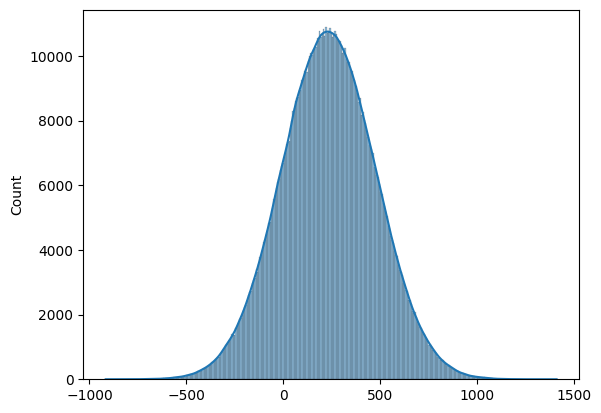

In [4]:
# Creating a population with normal distribution

rng = np.random.default_rng()
normal  =rng.normal(loc=232, scale=243, size=1000000)
sns.histplot(normal, kde=True)

In [6]:
# Calculating the mean and standard deviation manually

manual_mean = normal.sum() / len(normal)
print(f'Manual mean: {manual_mean:,.2f}')
manual_variance = float(np.sum((normal - manual_mean) ** 2) ) / len(normal)
print(f'Manual variance: {manual_variance:,.2f}')
manual_std = np.sqrt(manual_variance)
print(f'Manual std: {manual_std:,.2f}')


Manual mean: 232.37
Manual variance: 58,997.75
Manual std: 242.89


In [7]:
# Calculating the mean and standard deviation with formulas

normal_mean = normal.mean()
print(f'Normal mean: {normal_mean:,.2f}')
normal_variance = normal.var()
print(f'Normal variance: {normal_variance:,.2f}')
normal_std = normal.std()
print(f'Normal std: {normal_std:,.2f}')


Normal mean: 232.37
Normal variance: 58,997.75
Normal std: 242.89


## Standardization Z scores

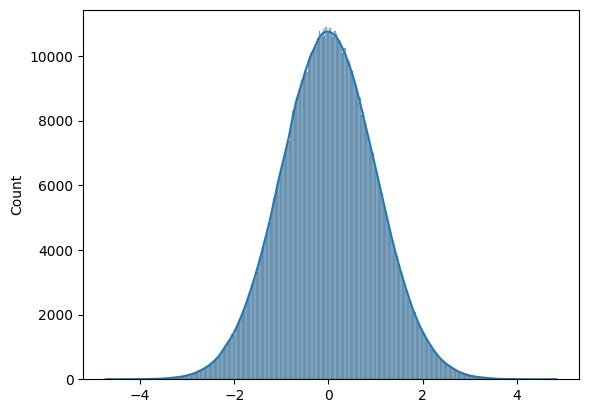

Mean of standardized data: 0.00


In [8]:
# Normalization
normal_normalized = (normal - normal_mean) / normal_std
sns.histplot(normal_normalized, kde=True)
plt.show()

print(f'Mean of standardized data: {normal_normalized.mean():,.2f}')

In [9]:
# Combining the two datasets: normal and normalized

all_normal = pd.DataFrame({'Normal': normal, 'Normal_normalized': normal_normalized})

all_normal.head()

,Normal,Normal_normalized
0,85.706612,-0.603804
1,601.639983,1.520301
2,424.358136,0.790429
3,362.311017,0.534980
4,61.829331,-0.702107


## Sampling


Manual calculations:

Sample mean: 235.17
Sample variance: 61,656.35
Sample standard deviation: 248.31
Sample Standard Error of the Mean: 7.85

Formula calculations:

Sample mean: 235.17
Sample variance: 61,656.35
Sample standard deviation: 248.31
Sample Standard Error of the Mean: 7.85


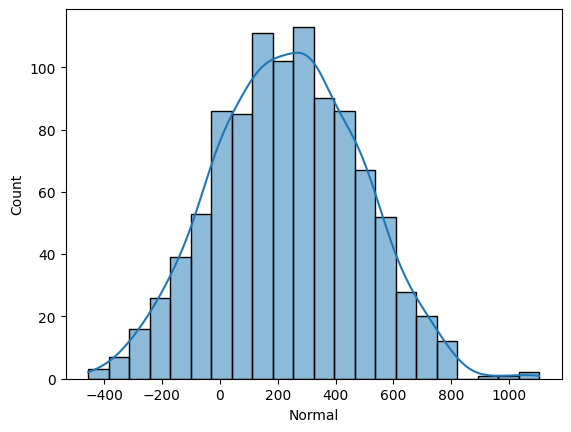

In [11]:
sample = all_normal['Normal'].sample(1000)
sns.histplot(sample, kde=True)

# Manual calculations
print('\nManual calculations:\n')
sample_mean = float(np.sum(sample)) / len(sample)
print(f'Sample mean: {sample_mean:,.2f}')

sample_variance = float(np.sum((sample - sample_mean)**2)) / (len(sample)-1)
print(f'Sample variance: {sample_variance:,.2f}')

sample_std = np.sqrt(sample_variance)
print(f'Sample standard deviation: {sample_std:,.2f}')

# Standard error
sample_sem = sample_std / np.sqrt(len(sample))
print(f'Sample Standard Error of the Mean: {sample_sem:,.2f}')

# Formula calculations
print('\nFormula calculations:\n')
for_sample_mean = sample.mean()
print(f'Sample mean: {for_sample_mean:,.2f}')

for_sample_variance = sample.var(ddof=1)
print(f'Sample variance: {for_sample_variance:,.2f}')

for_sample_std = np.std(sample, ddof=1)
print(f'Sample standard deviation: {for_sample_std:,.2f}')

for_sample_sem = stats.sem(sample)
print(f'Sample Standard Error of the Mean: {for_sample_sem:,.2f}')


Sample mean: 231.84


<Axes: ylabel='Count'>

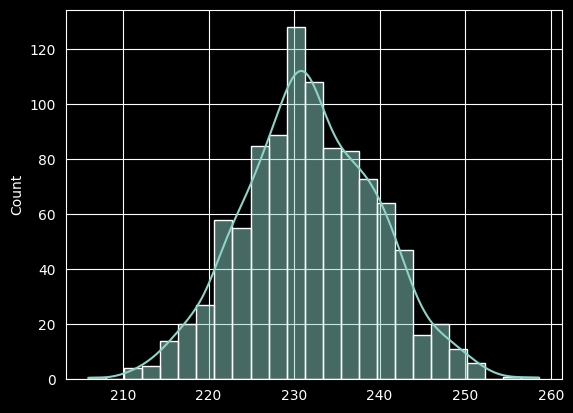

In [137]:
# Ongoing sampling

sample_means = []
for i in range(1000):
    sample_mean = all_normal['Normal'].sample(1000).mean()
    sample_means.append(sample_mean)

sample_means_np = np.array(sample_means)
print(f'Sample mean: {sample_means_np.mean():,.2f}')

sns.histplot(sample_means_np, kde=True)

<Axes: ylabel='Count'>

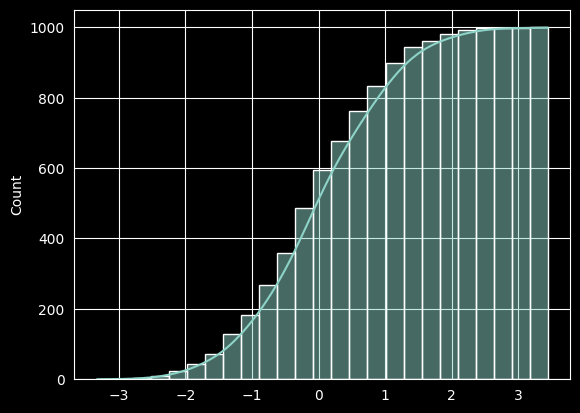

In [144]:
# Standardizing the sample means does not bring any specific value
standard_sample_means = stats.zscore(sample_means_np) #
# CDF
sns.histplot(standard_sample_means, kde=True, cumulative=False)

# Exponential distribution

<Axes: ylabel='Count'>

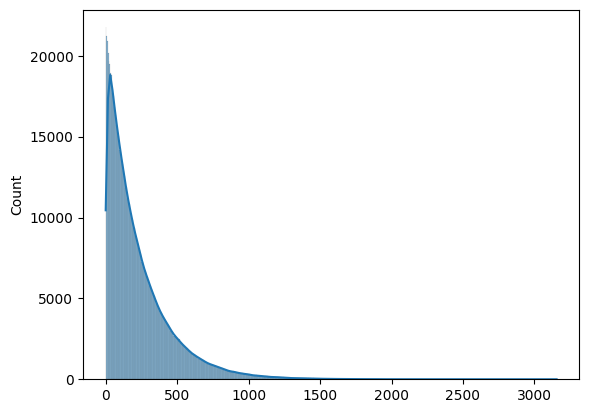

In [13]:
# Creating a population with exponential distribution

rng = np.random.default_rng()
expo = rng.exponential(scale=232, size=1000000)
sns.histplot(expo, kde=True)

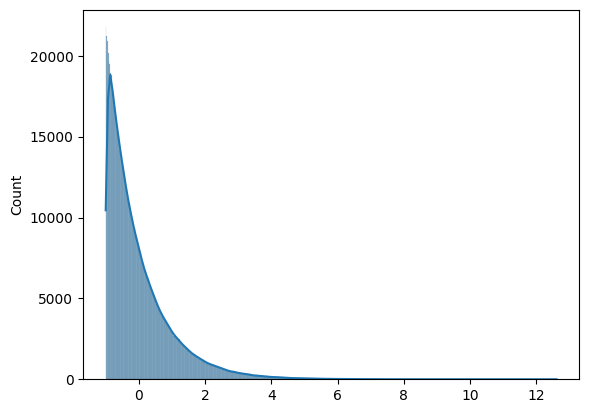

In [14]:
expo_zscore = stats.zscore(expo)
sns.histplot(expo_zscore, kde=True)

all_expo = pd.DataFrame({'Exponential': expo, 'Exponential_zscore': expo_zscore})

## Central Limit Theorem

<Axes: ylabel='Count'>

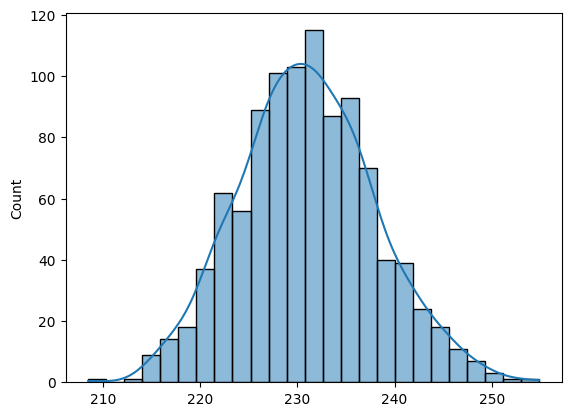

In [15]:
expo_means = []
for i in range(1000):
    expo_mean = all_expo['Exponential'].sample(1000).mean()
    expo_means.append(expo_mean)

sns.histplot(expo_means, kde=True)

# Hypothesis testing

In [ ]:
# TODO 1. Power of a test
# TODO 2. Cohen distance